In [13]:
from pathlib import Path

import kagglehub
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

In [2]:
dataset_path = kagglehub.dataset_download("zalando-research/fashionmnist")
dataset_path = Path(dataset_path)
print("Path to dataset files:", dataset_path)

Path to dataset files: /home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [3]:
for p in Path(dataset_path).iterdir():
    print(p)

/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/fashion-mnist_test.csv
/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/fashion-mnist_train.csv
/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/t10k-images-idx3-ubyte
/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/t10k-labels-idx1-ubyte
/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/train-images-idx3-ubyte
/home/dom/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/train-labels-idx1-ubyte


In [4]:
df = pd.read_csv(dataset_path/"fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test_df = pd.read_csv(dataset_path/"fashion-mnist_test.csv")
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

In [7]:
test_df.shape

(10000, 785)

In [8]:
LABEL_NAMES = [
    "0.T-shirt",
    "1.Trouser",
    "2.Pullover",
    "3.Dress",
    "4.Coat",
    "5.Sandal",
    "6.Shirt",
    "7.Sneaker",
    "8.Bag",
    "9.Ankle boot",
]

<Axes: >

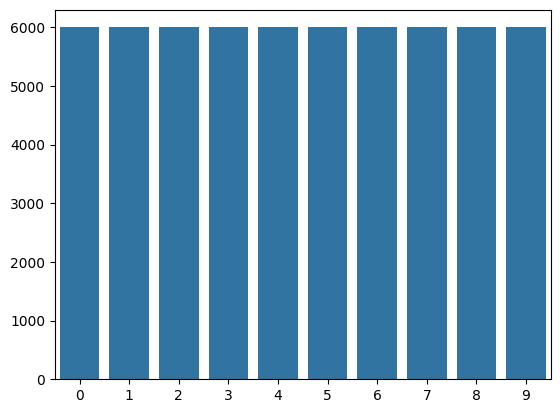

In [9]:
counts = np.zeros_like(LABEL_NAMES, dtype=int)
for i in range(counts.shape[0]):
    counts[i] = np.sum(df["label"] == i)

sns.barplot(counts)

<Axes: >

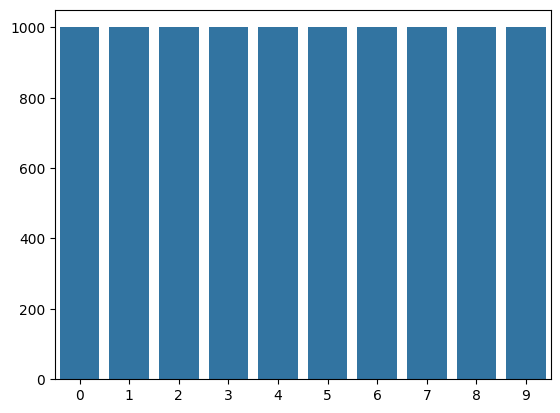

In [10]:
counts = np.zeros_like(LABEL_NAMES, dtype=int)
for i in range(counts.shape[0]):
    counts[i] = np.sum(test_df["label"] == i)

sns.barplot(counts)

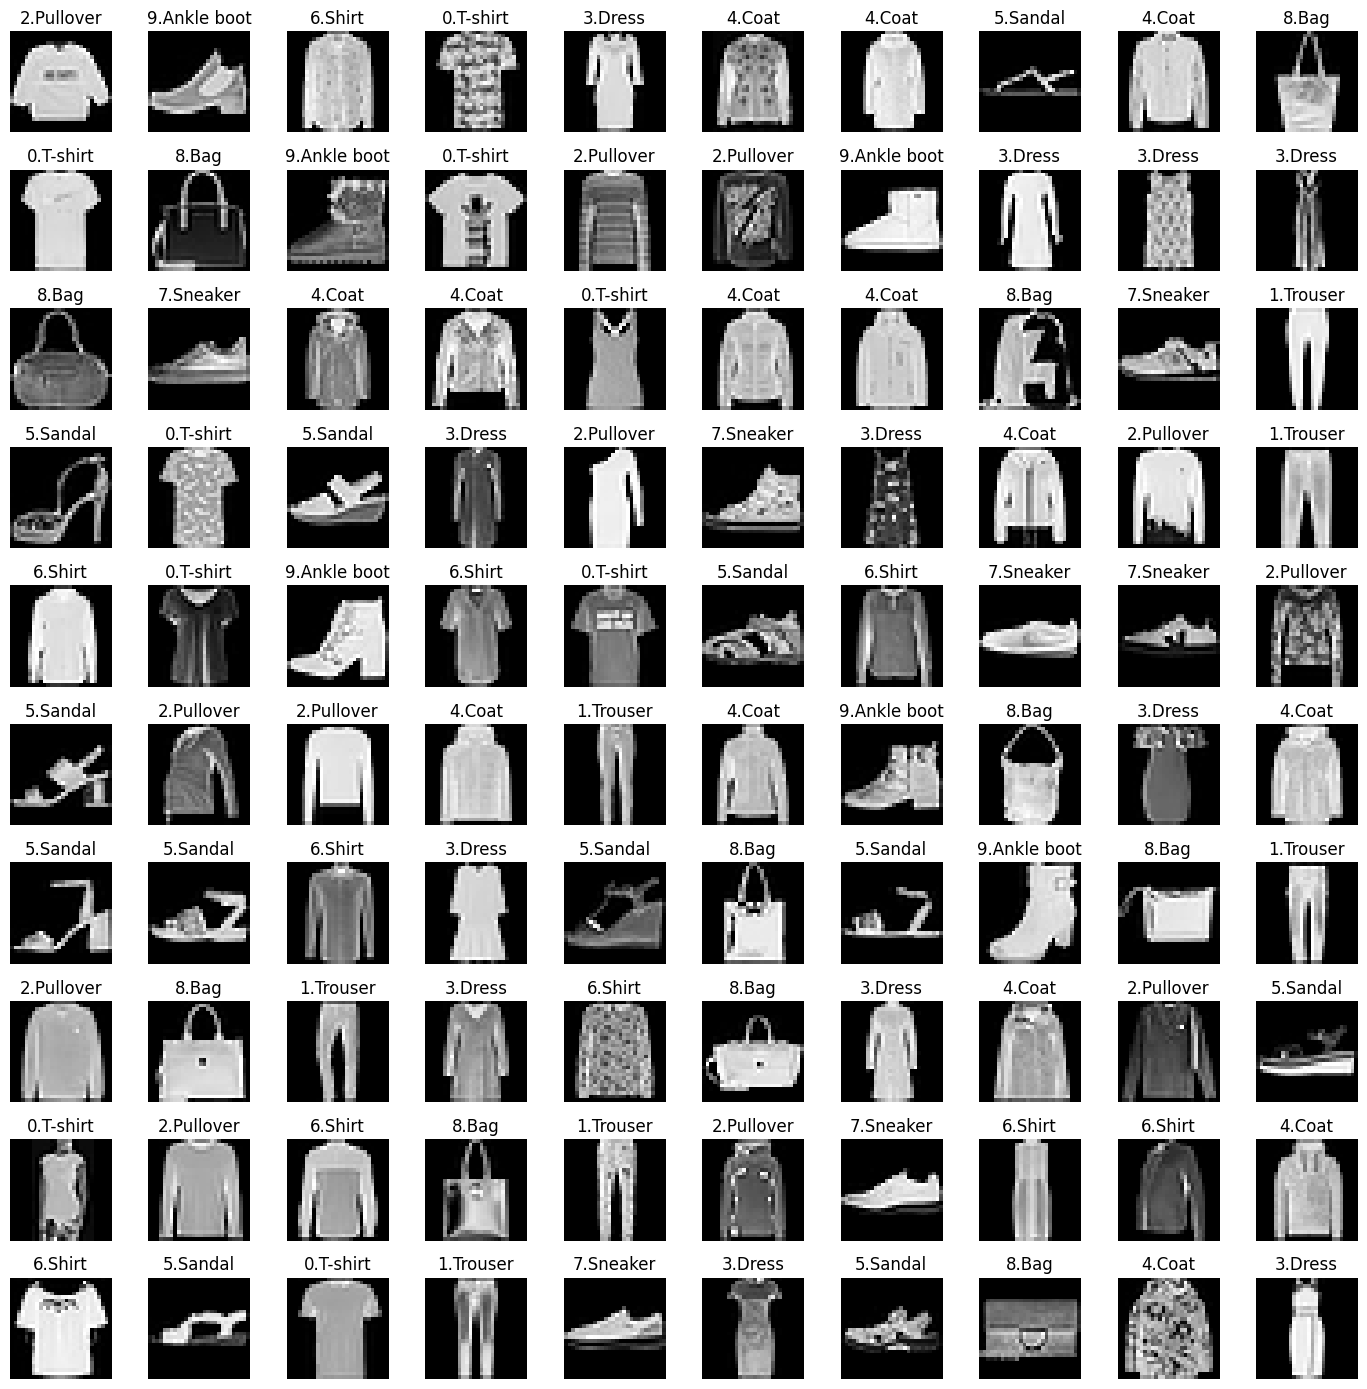

In [11]:
fig, axs = plt.subplots(10, 10, figsize=(14, 14))
axs = axs.flatten()
for ax, (index, row) in zip(axs, df[:axs.size].iterrows()):
    img = np.array(row[df.columns.drop(["label"])]).reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(LABEL_NAMES[row.label])

plt.tight_layout()
plt.show()

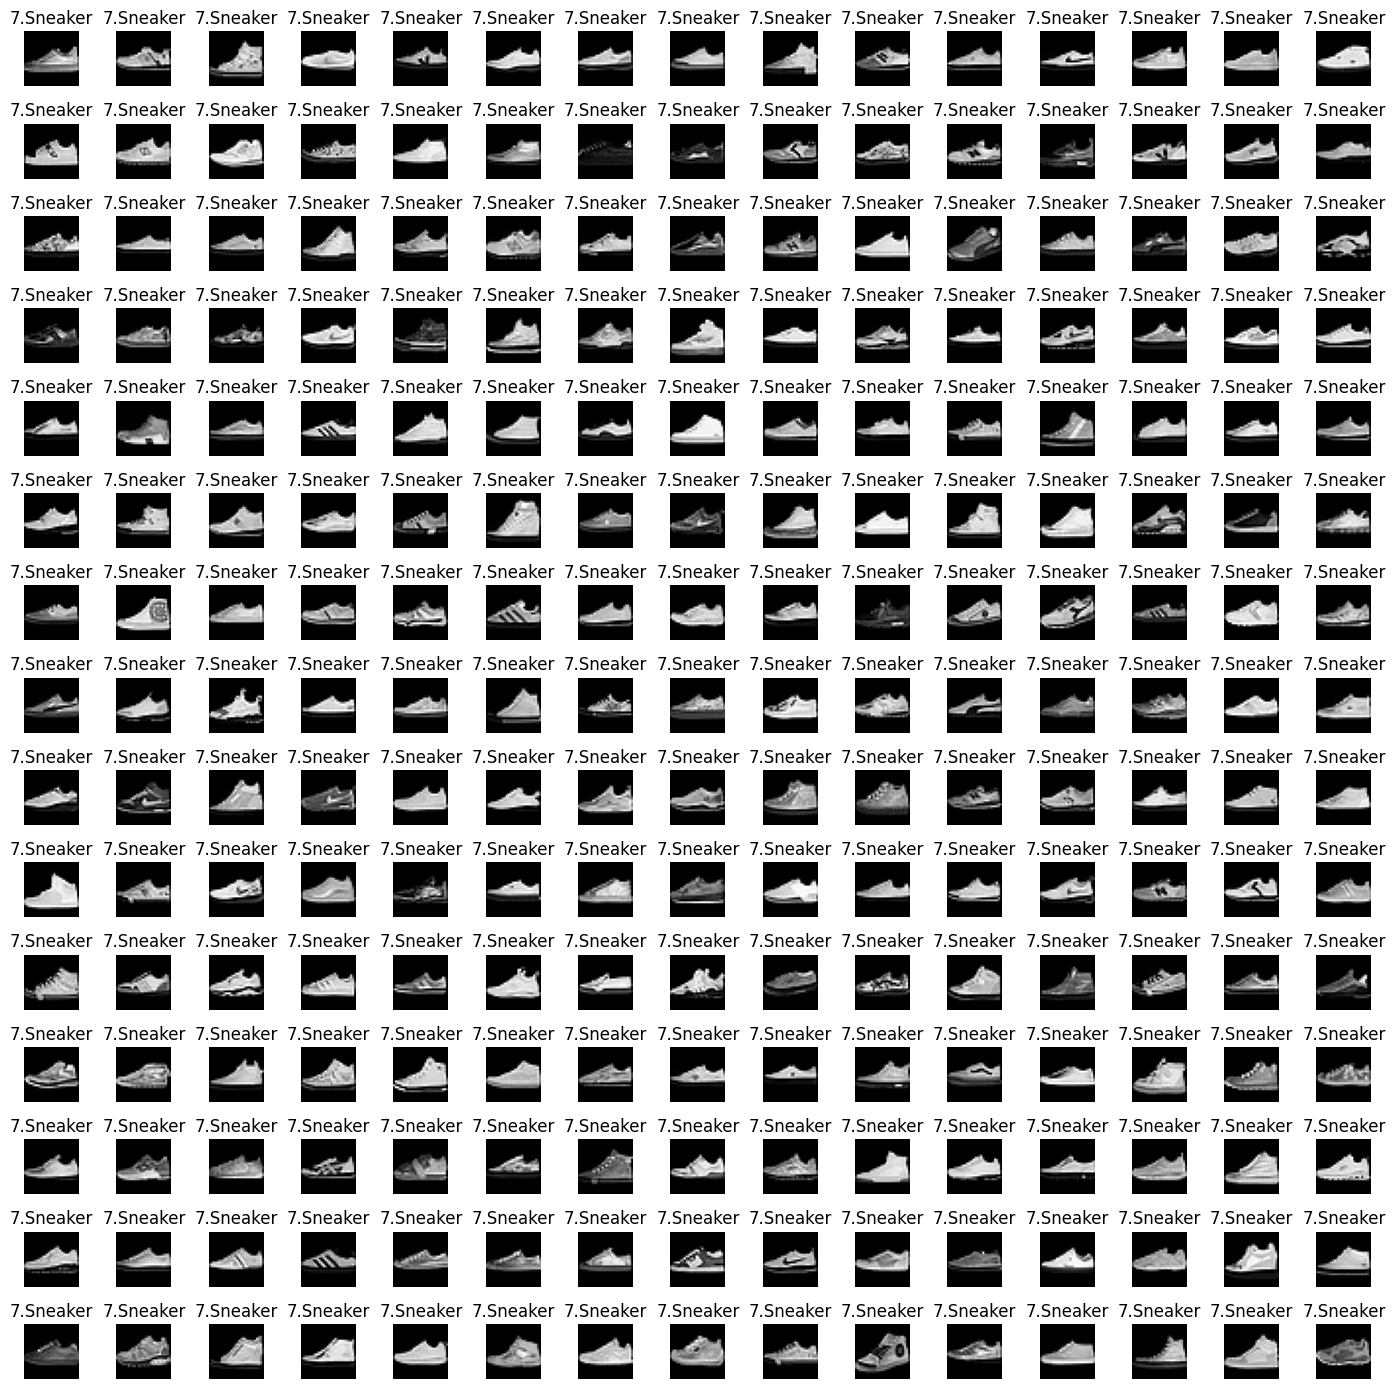

In [12]:
fig, axs = plt.subplots(15, 15, figsize=(14, 14))
axs = axs.flatten()
i = 0

for _, row in df[df["label"] == 7].iterrows():
    img = np.array(row[df.columns.drop(["label"])]).reshape(28, 28)
    ax = axs[i]
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(LABEL_NAMES[row.label])

    i += 1
    if i >= axs.size:
        break

plt.tight_layout()
plt.show()

In [24]:
X_train = df.drop("label", axis=1).to_numpy(dtype=float)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_train = X_train / 255.0
X_train = X_train.reshape(-1, 1, 28, 28)
X_train.shape, X_train.min(), X_train.max(), X_train.mean(), X_train.std()

(torch.Size([60000, 1, 28, 28]),
 tensor(0.),
 tensor(1.),
 tensor(0.2861),
 tensor(0.3528))

<Axes: ylabel='Count'>

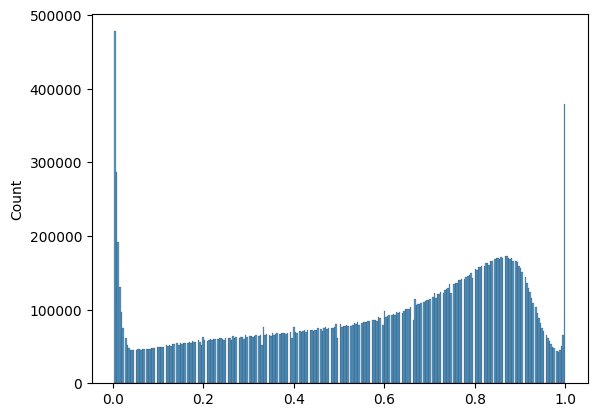

In [27]:
sns.histplot(X_train[X_train > 0.0].flatten())

In [28]:
y_train_val = torch.tensor(df["label"].values, dtype=torch.long)
y_train_val

tensor([2, 9, 6,  ..., 8, 8, 7])